# Deconvolve the replicating timing for the 10k bin curves using the Haar wavelet for a step-wise result

April 30, 2024

Compute the replicating timing from the deconvolved MNase-seq 10k windows for each gene.

**Goal:** Deconvolve the replication timing such that the result is a step-wise function
from G1 of copy number 1, S-phase (transition from 1 to 2 step-wise), and G2M as copy number 2.


In [4]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()
mnase_analysis_rep1.compute_replication_timing()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:29.261


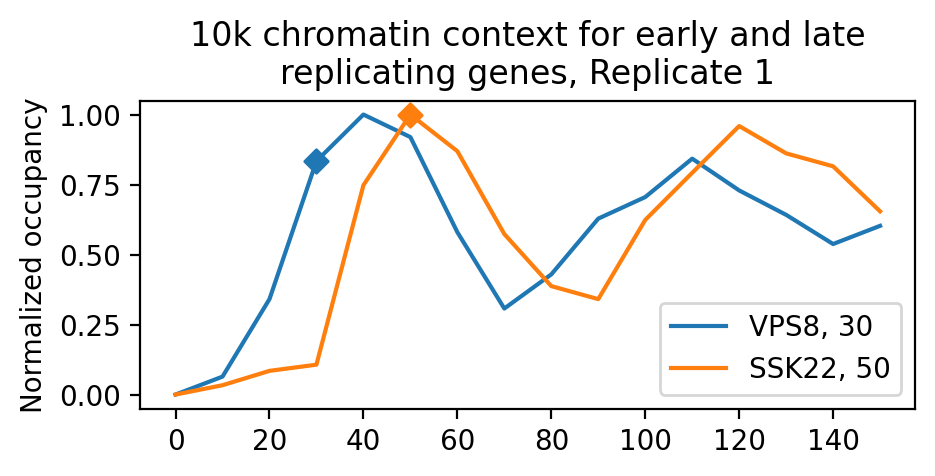

In [6]:
mnase_analysis_rep1.plot_normalized_bin_curves(['VPS8', 'SSK22'])

In [7]:
from src.sgd import get_orfname

orfname = get_orfname('CLN1')
#g = mnase_analysis_rep1.normalized_bin_curves.loc[orfname].values.reshape((-1, 1))
g = mnase_analysis_rep1.normalized_bin_curves.iloc[0:100].values.T

g = g + 1.
g.shape

(16, 100)

In [68]:
from src.geneset import get_deconvolved_geneset

geneset = get_deconvolved_geneset()

chr_genes = geneset[geneset.chr == 10]

chr_curves = mnase_analysis_rep1.normalized_bin_curves.join(chr_genes[[]], how='inner')
g = chr_curves.values.T

g = g + 1.

In [69]:
from src.dynamic_config_alpha import create_dynamic_alpha_config
from src.replication_deconvolution_solver import ReplicationChromatinDeconvolveSolver

In [213]:
config = create_dynamic_alpha_config(replicate=1, alpha=28)
solver = ReplicationChromatinDeconvolveSolver(config, g, wavelet='Haar')
solver.define_deconvolution_problem()
_ = solver.solve(gamma_value=0.001, verbose=False)

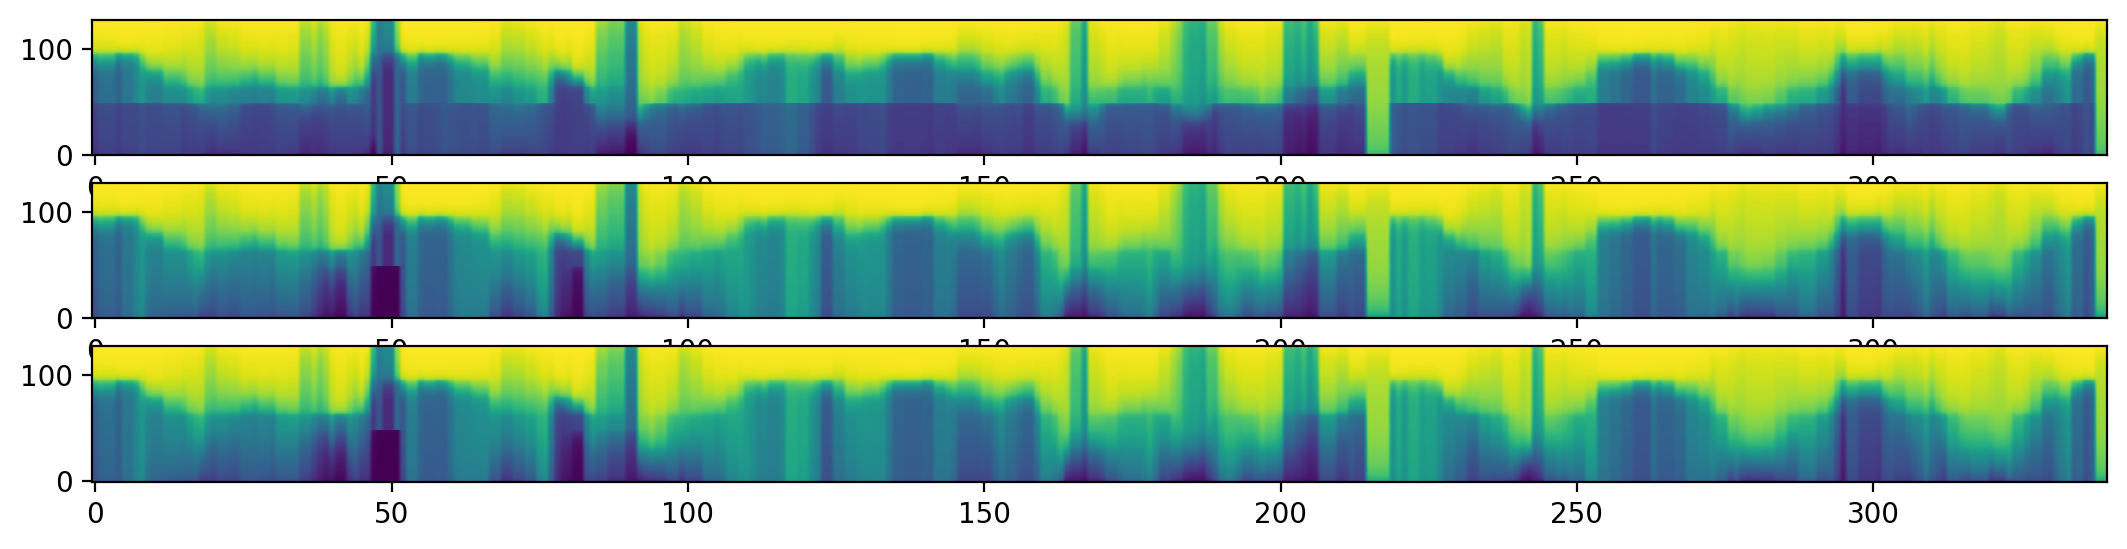

In [219]:
solver.plot_replication_hm(normalize=True)

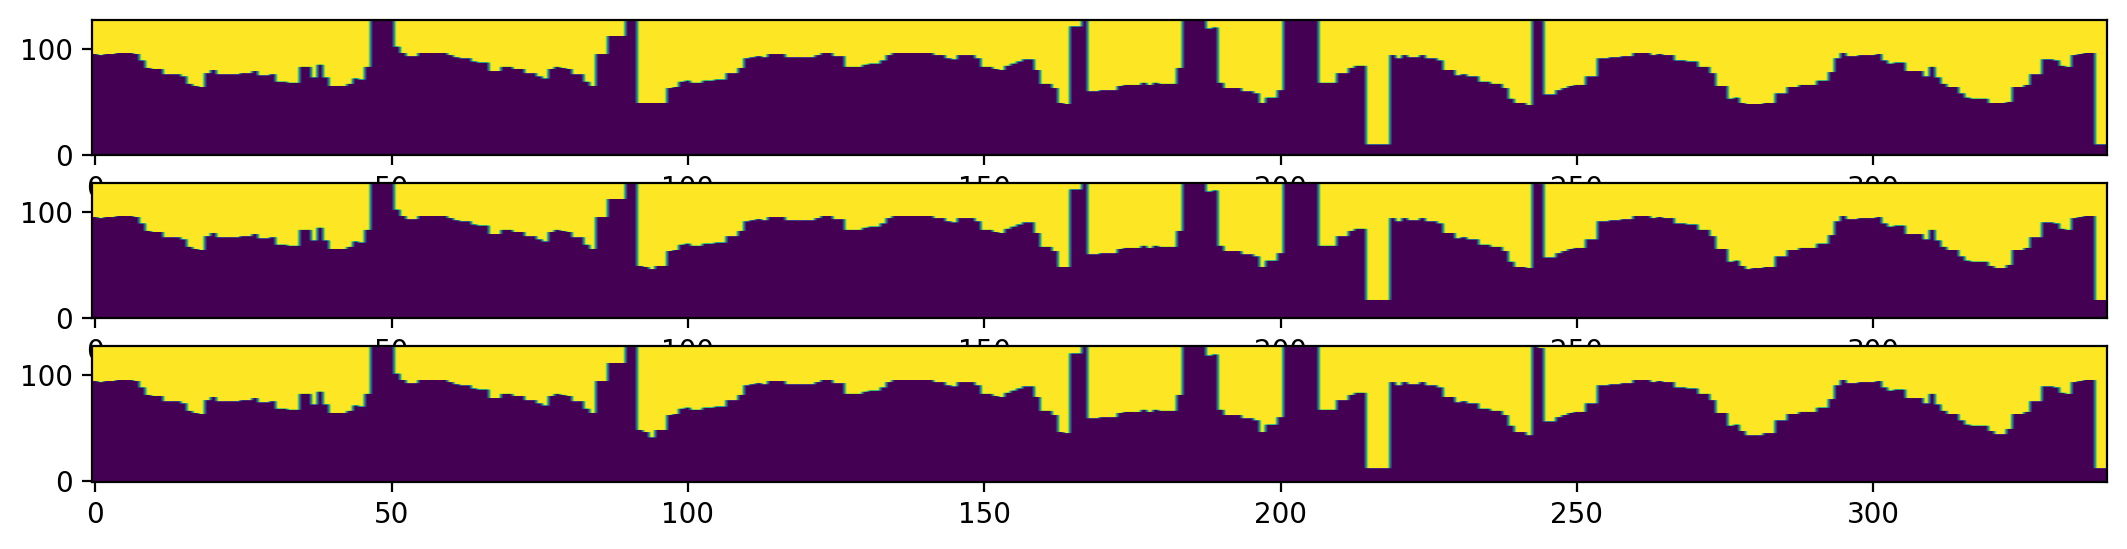

In [220]:
solver.plot_replication_hm(normalize=True, mask=True)

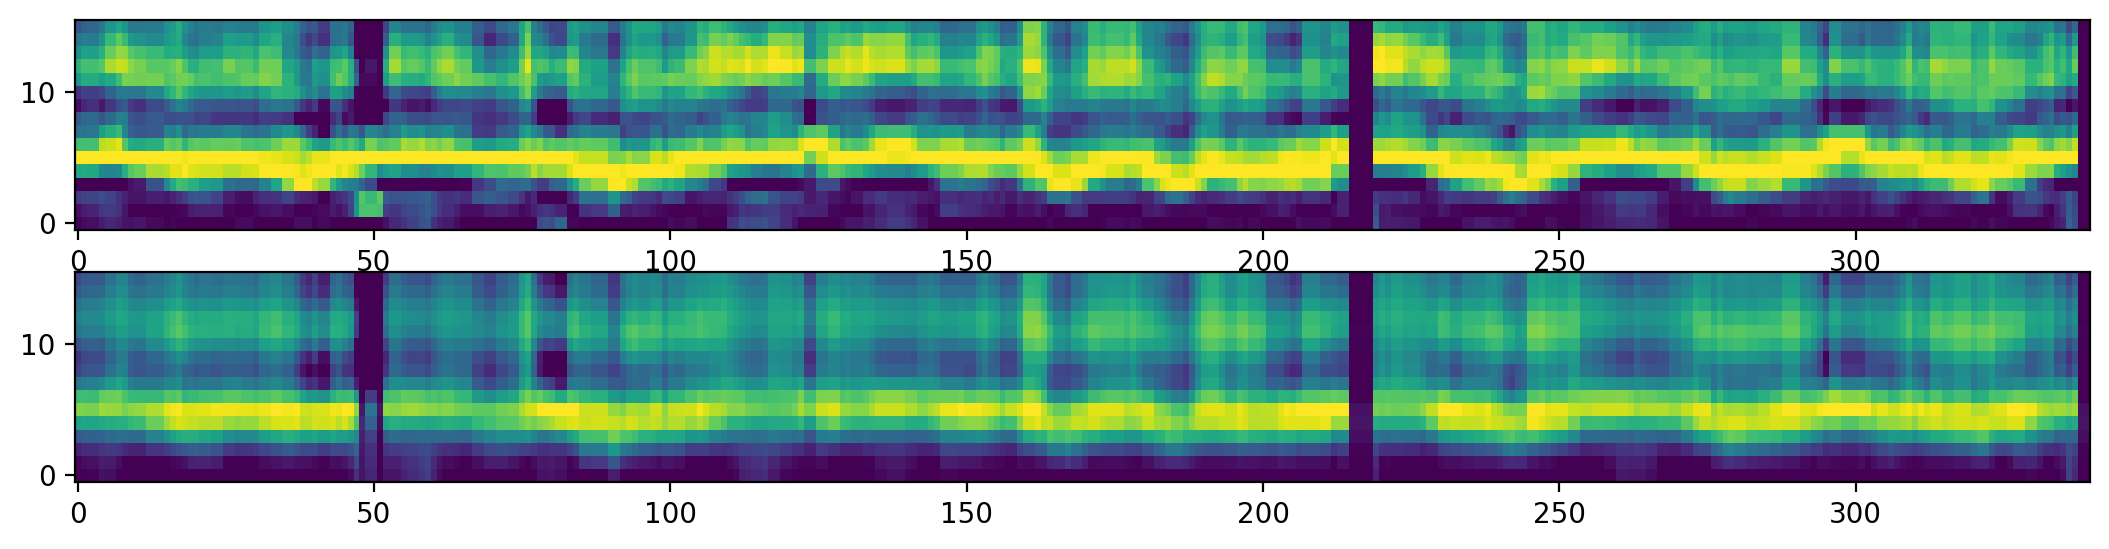

In [215]:
solver.plot_raw_predicted()

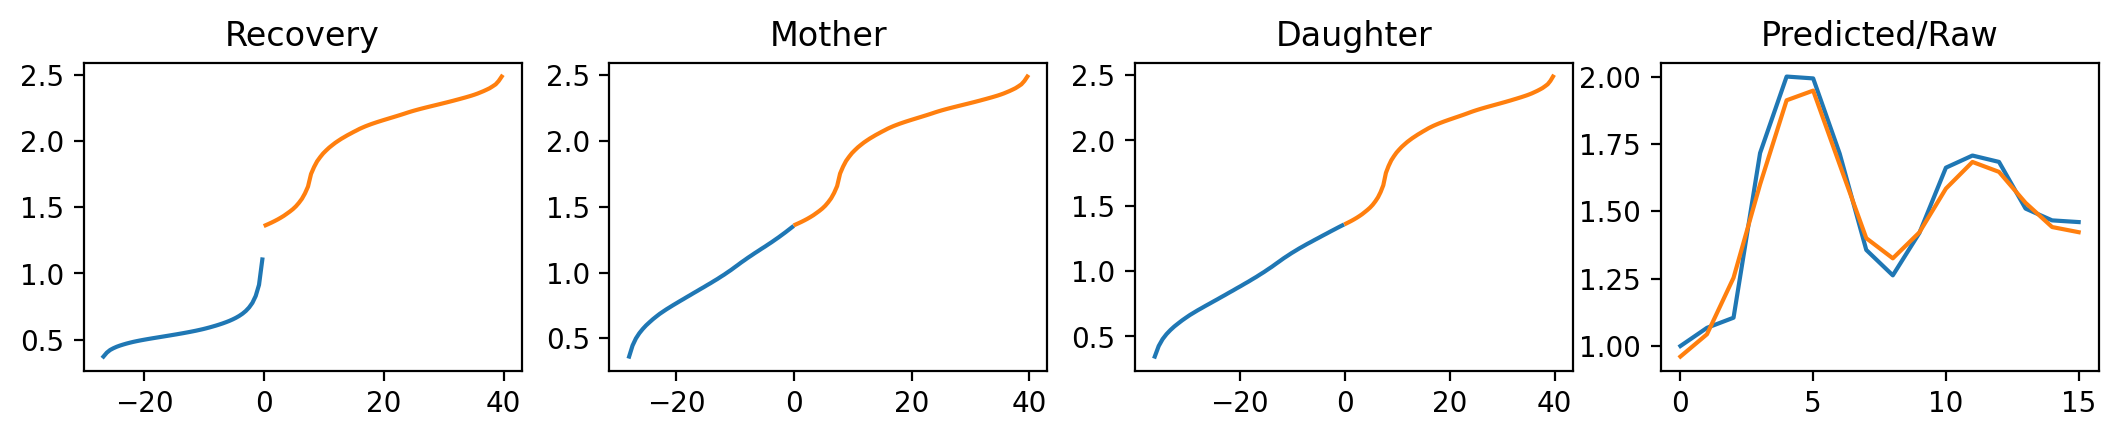

In [216]:
solver.plot_result(180)

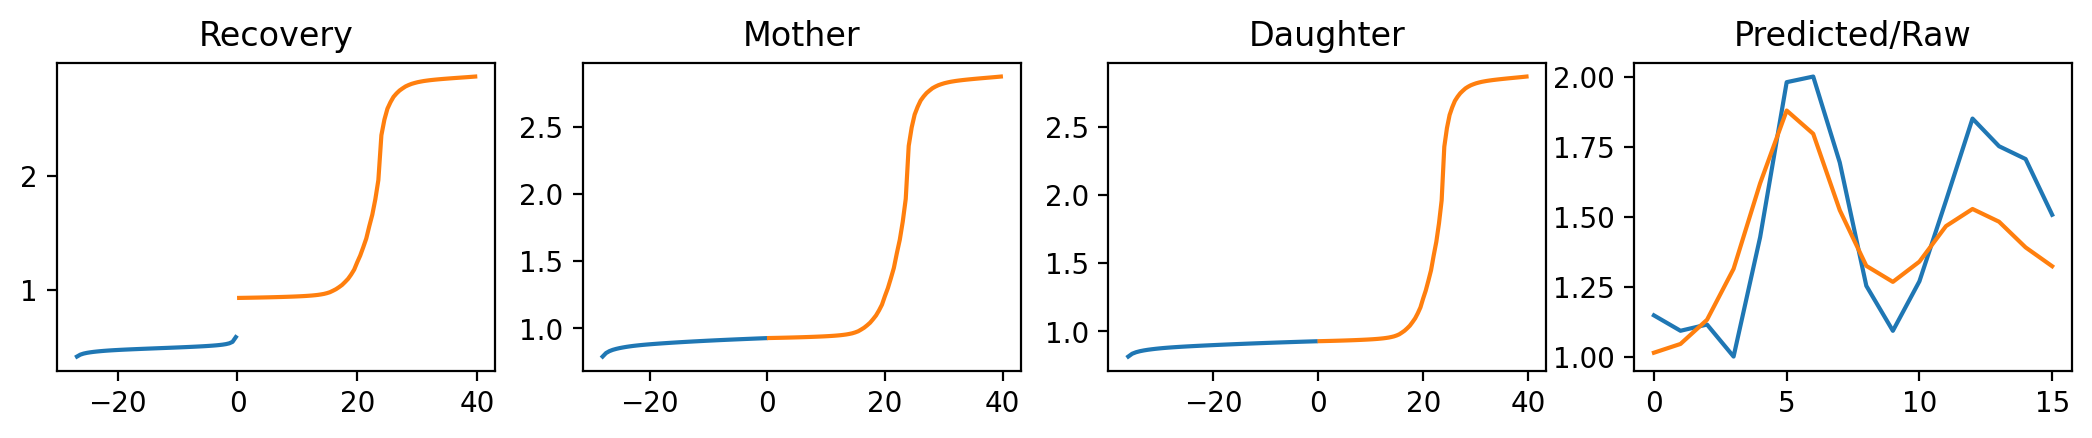

In [217]:
solver.plot_result(140)

In [193]:
# Some questions:   
#
# Will we need to do a sweep of find alpha? 
#    It would be helpful to be able to stick to alpha=28
# Will the combined model improve upon these results?
# 
# Observations:
#
# When gamma for Haar is high:
#   It appears the model tends to identify two modes at 0 and 20 min for replication times
#   Rather than identifying the nuances of the original data.
#
# When gamma is low
#   The model tends to create a linear curve (non-step-wise)
